# Principle-wise model aligment comparison


In [1]:
from pathlib import Path
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_DIR = Path('eval')  
FILE_PATTERN = 'eval_*.json'

def parse_filename(path: Path):
    name = path.stem 
    parts = name.split('_')
    parts = parts[1:]
    if not parts:
        return {"model": "unknown", "setting": "unknown", "raw_name": name}

    if len(parts) == 1:
        model = parts[0]
        setting = 'na'
    else:
        *model_tokens, setting = parts
        model = '_'.join(model_tokens)

    return {"model": model, "setting": setting, "raw_name": name}

files = sorted(DATA_DIR.glob(FILE_PATTERN))
files

[PosixPath('eval/eval_base_dpo_0.5.json'),
 PosixPath('eval/eval_base_dpo_1.json'),
 PosixPath('eval/eval_base_dpo_greedy.json'),
 PosixPath('eval/eval_base_sft_0.5.json'),
 PosixPath('eval/eval_base_sft_1.json'),
 PosixPath('eval/eval_base_sft_greedy.json'),
 PosixPath('eval/eval_base_sft_mistral_base_0.5.json'),
 PosixPath('eval/eval_base_sft_mistral_base_1.json'),
 PosixPath('eval/eval_base_sft_mistral_base_greedy.json'),
 PosixPath('eval/eval_tuned_dpo_0.5.json'),
 PosixPath('eval/eval_tuned_dpo_1.json'),
 PosixPath('eval/eval_tuned_dpo_greedy.json'),
 PosixPath('eval/eval_tuned_sft_0.5.json'),
 PosixPath('eval/eval_tuned_sft_1.json'),
 PosixPath('eval/eval_tuned_sft_greedy.json'),
 PosixPath('eval/eval_tuned_sft_mistral_base_0.5.json'),
 PosixPath('eval/eval_tuned_sft_mistral_base_1.json'),
 PosixPath('eval/eval_tuned_sft_mistral_base_greedy.json')]

In [ ]:
rubric_pattern = re.compile(r"\[(.*?)\]\s*--\s*(\d+)")

def load_eval_file(path: Path) -> pd.DataFrame:
    meta = parse_filename(path)
    with path.open('r', encoding='utf-8') as f:
        data = json.load(f)

    summary_scores = data[0]

    principle_names = None
    for entry in data[1:]:
        if isinstance(entry, list) and len(entry) == 2 and isinstance(entry[1], str):
            names = [m.group(1) for m in rubric_pattern.finditer(entry[1])]
            if names:
                principle_names = names
                break

    if principle_names is None or len(principle_names) != len(summary_scores):
        principle_names = [f"Principle {i+1}" for i in range(len(summary_scores))]

    rows = []
    for i, score in enumerate(summary_scores):
        rows.append({
            'file': meta['raw_name'],
            'model': meta['model'],
            'setting': meta['setting'],
            'example_idx': 0,  
            'principle': principle_names[i],
            'score': float(score),
        })

    return pd.DataFrame(rows)

if files:
    df_test = load_eval_file(files[0])
    display(df_test.head())
else:
    print("No eval_*.json files found in", DATA_DIR)


,file,model,setting,example_idx,principle,score
0,eval_base_dpo_0.5,base_dpo,0.5,0,Authentic Voice Alignment,2.87
1,eval_base_dpo_0.5,base_dpo,0.5,0,Direct and Thoughtful Response,3.55
2,eval_base_dpo_0.5,base_dpo,0.5,0,Precision and Accuracy,2.29
3,eval_base_dpo_0.5,base_dpo,0.5,0,Explain Causes and Risks,2.55
4,eval_base_dpo_0.5,base_dpo,0.5,0,Comprehensive Helpfulness,2.71


In [4]:
all_dfs = []
for path in files:
    df = load_eval_file(path)
    if not df.empty:
        all_dfs.append(df)

if not all_dfs:
    raise RuntimeError("No data extracted – check your paths and file format.")

df = pd.concat(all_dfs, ignore_index=True)
df.head()


,file,model,setting,example_idx,principle,score
0,eval_base_dpo_0.5,base_dpo,0.5,0,Authentic Voice Alignment,2.87
1,eval_base_dpo_0.5,base_dpo,0.5,0,Direct and Thoughtful Response,3.55
2,eval_base_dpo_0.5,base_dpo,0.5,0,Precision and Accuracy,2.29
3,eval_base_dpo_0.5,base_dpo,0.5,0,Explain Causes and Risks,2.55
4,eval_base_dpo_0.5,base_dpo,0.5,0,Comprehensive Helpfulness,2.71


In [5]:
def normalize(row):
    m = row["model"]
    s = row["setting"]

    if m.startswith("base_dpo"):
        base = "base_dpo"
    elif m.startswith("tuned_sft_mistral"):
        base = "tuned_sft_mistral"
    elif m.startswith("base_sft_mistral"):
        base = "base_sft_mistral"
    elif m.startswith("base_sft"):
        base = "base_sft"
    elif m.startswith("tuned_dpo"):
        base = "tuned_dpo"
    elif m.startswith("tuned_sft"):
        base = "tuned_sft"
    else:
        base = m

    # map to numeric temperature
    if s == "greedy":
        temp = 0.0
    elif s.startswith("temp_"):
        temp = float(s.replace("temp_", ""))
    else:
        temp = float(s)

    return pd.Series({"model_clean": base, "temp": temp})


df_norm = df.copy()
df_norm[["model_clean", "temp"]] = df_norm.apply(normalize, axis=1)

display(df_norm.head())

,file,model,setting,example_idx,principle,score,model_clean,temp
0,eval_base_dpo_0.5,base_dpo,0.5,0,Authentic Voice Alignment,2.87,base_dpo,0.5
1,eval_base_dpo_0.5,base_dpo,0.5,0,Direct and Thoughtful Response,3.55,base_dpo,0.5
2,eval_base_dpo_0.5,base_dpo,0.5,0,Precision and Accuracy,2.29,base_dpo,0.5
3,eval_base_dpo_0.5,base_dpo,0.5,0,Explain Causes and Risks,2.55,base_dpo,0.5
4,eval_base_dpo_0.5,base_dpo,0.5,0,Comprehensive Helpfulness,2.71,base_dpo,0.5


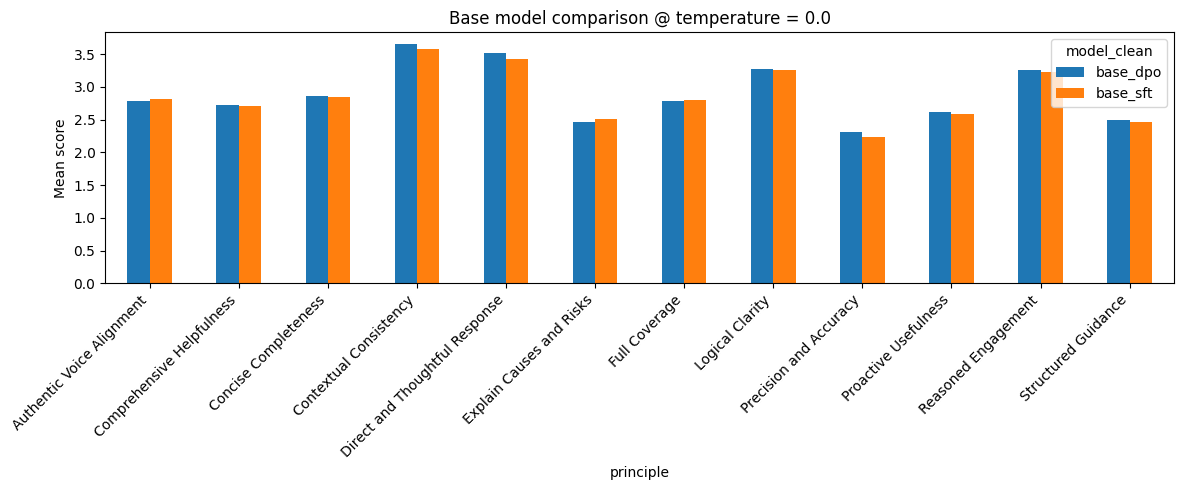

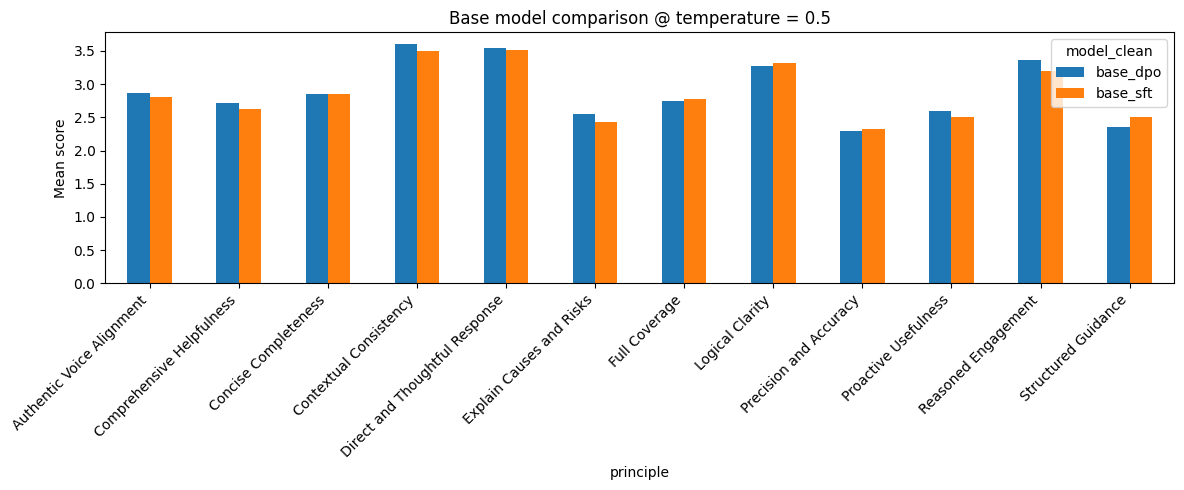

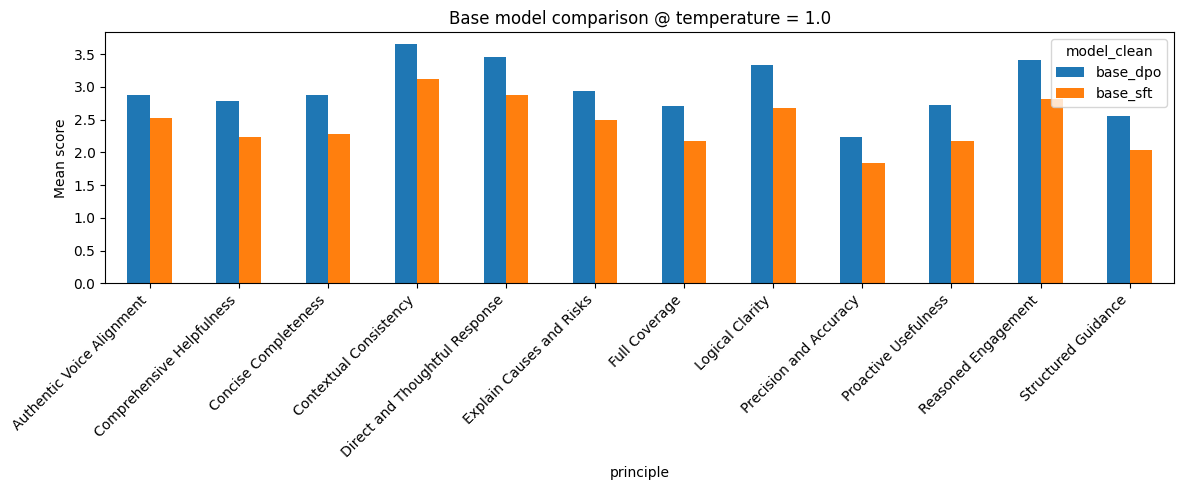

In [6]:
temps = sorted(df_norm["temp"].unique())

for t in temps:
    sub = df_norm[(df_norm["temp"] == t) &
                  (df_norm["model_clean"].isin(["base_dpo", "base_sft"]))]

    if sub.empty:
        continue

    pivot = sub.pivot_table(index="principle",
                            columns="model_clean",
                            values="score",
                            aggfunc="mean")

    pivot.plot(kind="bar", figsize=(12, 5))
    plt.title(f"Base model comparison @ temperature = {t}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean score")
    plt.tight_layout()
    plt.show()

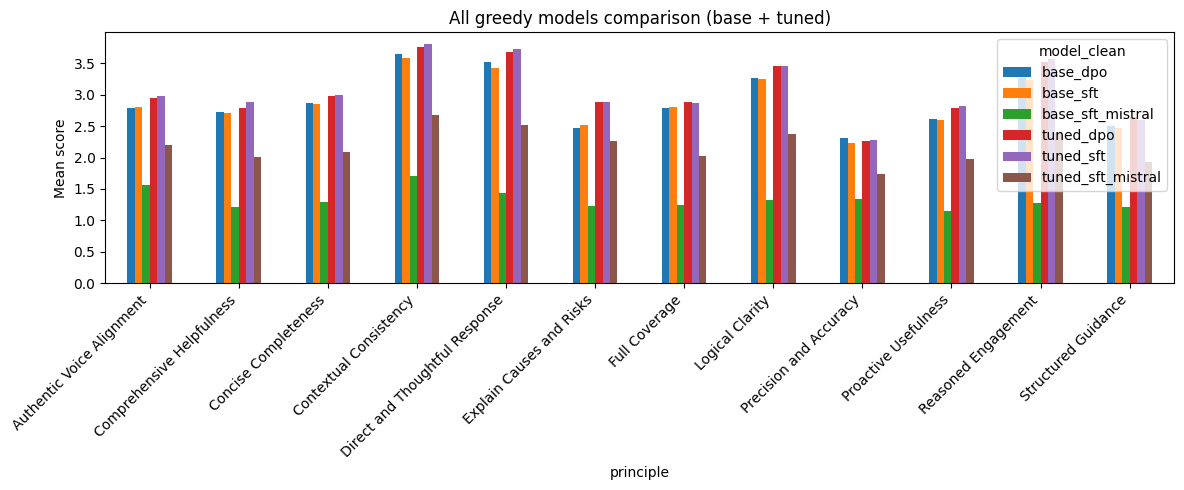

In [7]:
sub_greedy = df_norm[df_norm["temp"] == 0.0]

pivot = sub_greedy.pivot_table(index="principle",
                               columns="model_clean",
                               values="score",
                               aggfunc="mean")

pivot.plot(kind="bar", figsize=(12, 5))
plt.title("All greedy models comparison (base + tuned)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean score")
plt.tight_layout()
plt.show()

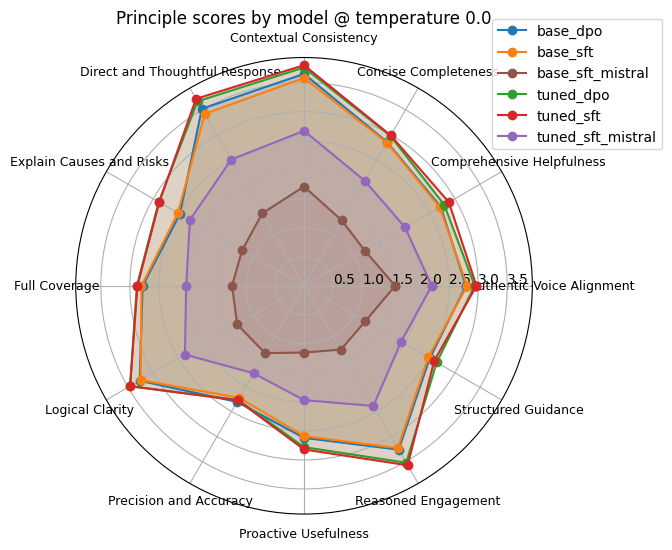

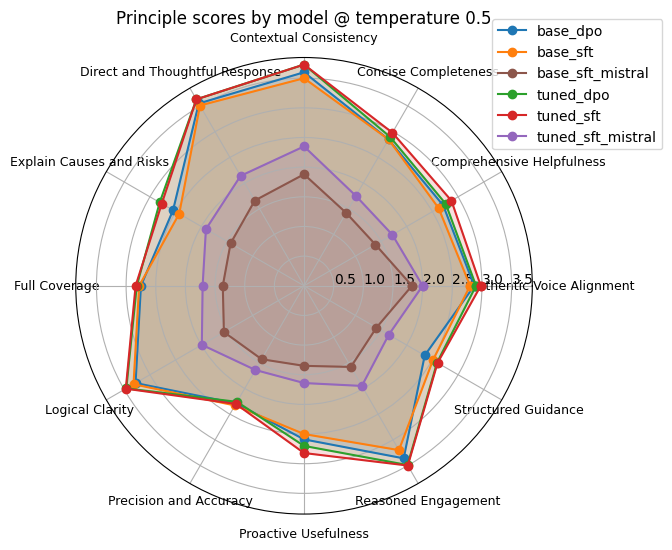

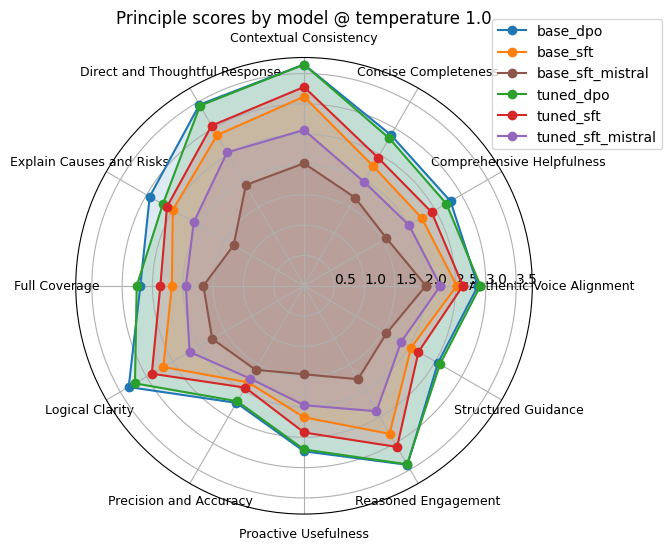

In [ ]:
model_colors = {
    "base_dpo": "C0",
    "base_sft": "C1",
    "tuned_dpo": "C2",
    "tuned_sft": "C3",
    "tuned_sft_mistral": "C4",
    "base_sft_mistral": "C5"
}

def radar_by_temp(temp_value, df_norm):
    sub = df_norm[df_norm["temp"] == temp_value]
    if sub.empty:
        print(f"No data for temperature {temp_value}")
        return
    
    # rows: principles, columns: models, values: mean score
    pivot = sub.pivot_table(
        index="principle",
        columns="model_clean",
        values="score",
        aggfunc="mean",
    ).sort_index()

    principles = pivot.index.tolist()
    n_axes = len(principles)

    angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, polar=True)

    for model in pivot.columns:
        values = pivot[model].values
        values = np.concatenate([values, [values[0]]]) 
        color = model_colors.get(model, None)
        ax.plot(angles, values, marker="o", label=model, color=color)
        ax.fill(angles, values, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(principles, fontsize=9)
    ax.set_title(f"Principle scores by model @ temperature {temp_value}")
    ax.set_rlabel_position(0)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

for t in sorted(df_norm["temp"].unique()):
    radar_by_temp(t, df_norm)

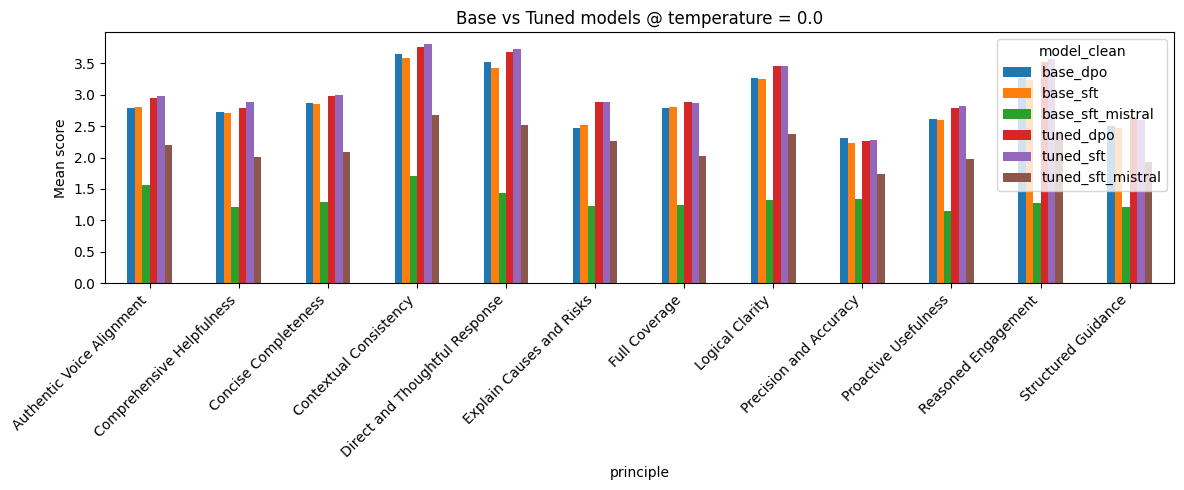

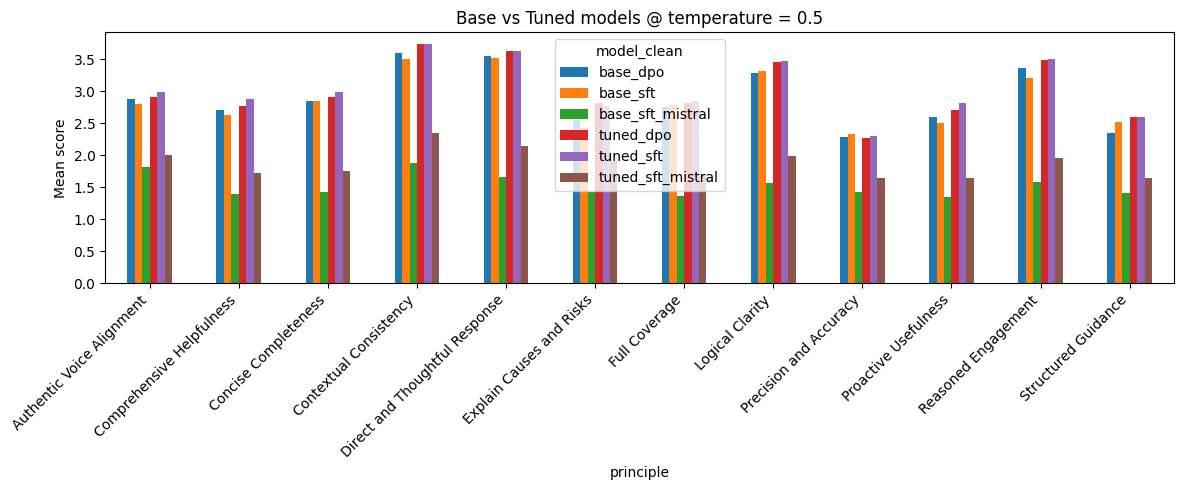

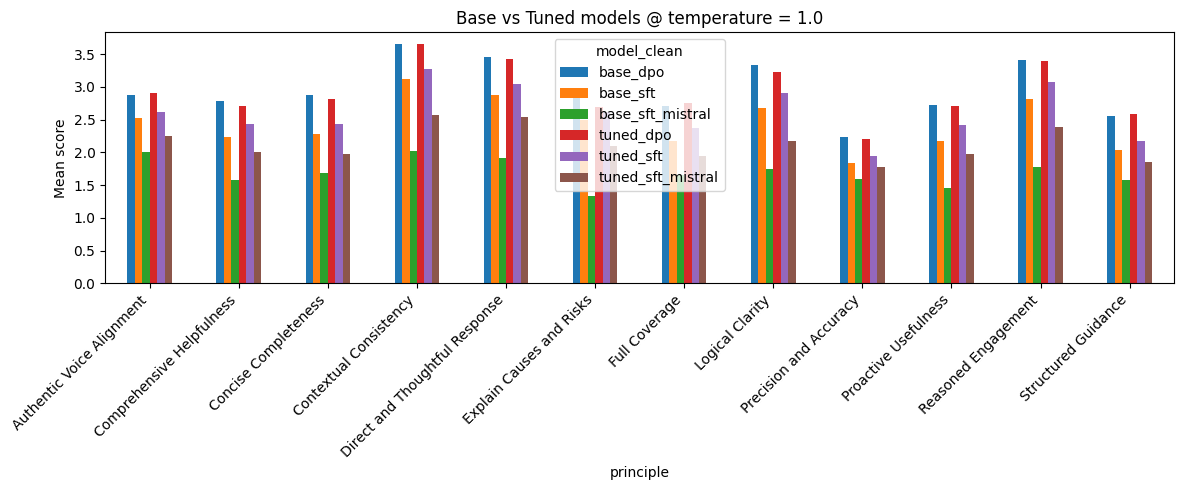

In [9]:
temps = sorted(df_norm["temp"].unique())

for t in temps:
    sub = df_norm[df_norm["temp"] == t]

    pivot = sub.pivot_table(index="principle",
                            columns="model_clean",
                            values="score",
                            aggfunc="mean")

    pivot.plot(kind="bar", figsize=(12,5))
    plt.title(f"Base vs Tuned models @ temperature = {t}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean score")
    plt.tight_layout()
    plt.show()